# Core Analysis

    1. Top counts tables (top 10–20) for:

        i. Most frequent peptides (top 20)

            a. The prevalence of the top 20 peptides in viruses and humans

            b. Peptides with viral + human overlaps

   
        ii. Most frequent accessions/proteins

        iii. Most frequent taxids and/or families (via lookup)


    3. Distributions/plots:

        i. Peptide frequency distribution (how often peptides repeat)

        ii. Counts per taxid/family (bar plot for top groups)

    4. Findings

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
mapped = pd.read_parquet("data_sampled_10_percent.parquet")
metadata = pd.read_parquet("lookup.parquet")

In [4]:
mapped.head(10)

,peptide,side,accession,position
0,AAAAAAGSS,human,XP_054224810.1,66
1,AAAAAAGSS,human,XP_054224809.1,66
2,AAAAAAGSS,human,XP_054224808.1,66
3,AAAAAAGSS,human,XP_054224807.1,66
4,AAAAAAGSS,human,XP_054224806.1,66
5,AAAAAAGSS,human,XP_054224805.1,66
6,AAAAAAGSS,human,KAI4074409.1,66
7,AAAAAAGSS,human,KAI4022240.1,9
8,AAAAAAGSS,human,KAI2538467.1,9
9,AAAAAAGSS,human,AWQ13361.1,66


# Top counts tables (top 10-20)

#### Most Frequent Peptides

In [31]:
from collections import Counter

freq = Counter(mapped["peptide"])

top_20 = pd.DataFrame(freq.most_common(20), columns = ["peptide","counts"])

top_20

,peptide,counts
0,LLQNGMNGR,233472
1,NGSCGSVGF,213019
2,FRKMAFPSG,208896
3,QNGMNGRTI,202905
4,CASLKELLQ,200704
5,YAAVINGDR,200704
6,TQDHVDILG,200049
7,VINGDRWFL,198706
8,CVLKLKVDT,198656
9,DLEGNFYGP,198656


Number of times every unique peptides occured were counted with python's Counter library. Looking at the table, the frequency of the most common peptides are generally close to each other, ranging from 230,000 to 190,000. This indicates that the mapped peptide chart is dominated by multiple peptides, rather than a single peptide or a few peptides. LLQNGMNGR is the most frequently occurring peptide, repeated 233.472 times.

#### The Prevalence of the Top 20 Peptides in Viruses and Humans

In [72]:
most_freq_pept = mapped.value_counts("peptide").head(20).reset_index(name = "counts")

filtered_mapped = mapped[mapped["peptide"].isin(most_freq_pept["peptide"])]

side_count_df = pd.pivot_table(
    filtered_mapped,
    index="peptide", 
    columns="side", 
    aggfunc="size",
    fill_value=0
)

side_count_df.reindex(most_freq_pept["peptide"])

side,human,virus
peptide,,
LLQNGMNGR,0,233472
NGSCGSVGF,0,213019
FRKMAFPSG,0,208896
QNGMNGRTI,4,202901
CASLKELLQ,0,200704
YAAVINGDR,0,200704
TQDHVDILG,0,200049
VINGDRWFL,0,198706
CVLKLKVDT,0,198656


A pivot table showing how much of these peptides are shared between viruses and humans. 

 It turned out that almost all of the first 20 peptides were viral peptides. Only the QNGMNGRTI peptide was seen 4 times in the mapped data for humans.

In [86]:
filtered_pept = mapped[mapped["peptide"].str.contains("QNGMNGRTI") & mapped["side"].str.contains("human")]

filtered_pept

,peptide,side,accession,position
66371733,QNGMNGRTI,human,pdb|9EWM|A,277
66371734,QNGMNGRTI,human,pdb|9EWO|A,277
66371735,QNGMNGRTI,human,pdb|9EWN|A,277
66371736,QNGMNGRTI,human,pdb|9EUS|B,277


- 4 of the human peptides belong to different pdb accessions. 

#### Peptides with Viral + Human Overlaps

In [97]:
# hem insanda hem de virüste bulunan peptitleri ve side bilgilerini getirelim.
side_count_df = pd.pivot_table(
    mapped,
    index="peptide", 
    columns="side", 
    aggfunc="size",
    fill_value=0
)

side_count_df.reindex(most_freq_pept["peptide"])

common_peptides = side_count_df[(side_count_df["human"] >= 10) & (side_count_df["virus"] >=10)]

common_peptides

side,human,virus
peptide,,
AAAAAAPAA,18,17
AAAAAAPAP,42,21
AAAAAASAA,19,52
AAAAAASAE,13,33
AAAAAASQQ,11,48
...,...,...
YQRSGDMGL,41,38
YRGNVGVVL,14,22
YRIDHYLGK,30,42


When the overlap value for viral human peptides is kept to a minimum (i.e., >= 1), 13,600 peptides are observed to overlap. When this number is increased further, e.g., >= 10, the number of shared peptides drops to 330.

Peptides with high-viral human overlap are the candidate for molecular mimicry and should be avoided as vaccine targets. This is important to minimize the risk of cross-reactivity and autoimmune responses.

Peptides exhibiting high human-viral overlap were not among the most frequently observed sequences. These motifs generally occurred with low frequency within the mapped data and are potentially molecular mimicry candidates.

Some Low complexity regions (LCR), like AAAAAAPAA, were also common between viruses and human in mapped data. These regions (LCRs) should be avoided for further analysis to enhance homology search.

#### Most Frequent Accessions of Proteins

In [6]:
most_freq_acc = mapped.value_counts("accession").head(20).reset_index(name = "counts")

most_freq_acc

,accession,counts
0,AMD82161.1,172
1,XCA58896.1,171
2,pdb|7KDG|C,157
3,WFH84898.1,153
4,WEW07189.1,151
5,WEW07420.1,151
6,UAM32625.1,150
7,WKP34631.1,150
8,UDE88663.1,150
9,UAM32321.1,149


 The most frequently occurring accessions of proteins also ranged between 170 and 150. No single protein that occurs frequently dominates the data. It can be conlcuded that as in the peptides, each protein shows a similar distribution within the mapped peptide data. The first three frequent accessions are found to be NCBI accessions AMD82161.1, XCA58896.1. The third most frequent is a pdb accession number.

#### Most Frequent Taxids and Families (via lookup)

In [7]:
most_freq_taxid = metadata.value_counts("taxid").head(20).reset_index(name = "counts")

most_freq_taxid

,taxid,counts
0,2697049,2427040
1,2832643,206094
2,38018,165194
3,11676,118348
4,11320,113384
5,10244,59477
6,2809302,14058
7,208893,12432
8,3052230,11494
9,208895,10757


The most frequent taxid in the mapped peptide data is 2697049, which is repeated 2.427.040 times. Taxid 2697049 dominates the data and threfore, there is no homogeneous distribution, as in the peptide and protein accessions.

In [8]:
most_freq_family = metadata.value_counts("family").head(20).reset_index(name = "counts")

most_freq_family

,family,counts
0,Coronaviridae,2444557
1,Poxviridae,77155
2,Straboviridae,59833
3,Phycodnaviridae,33915
4,Herelleviridae,33553
5,Orthoherpesviridae,25436
6,Flaviviridae,22892
7,Mimiviridae,20504
8,Microviridae,18507
9,Kyanoviridae,18384


Coronaviridae is the most frequent family, accounting for nearly all peptide mapping data, with 2.444.557 repeats. This shows that the overall mapped peptide data is heavily driven by a single viral family.

# Distributions/ Plots

#### Peptide Frequency Distribution (How Often Peptides Repeat)

In [9]:
df_pept_freq = pd.DataFrame(mapped.value_counts("peptide"))

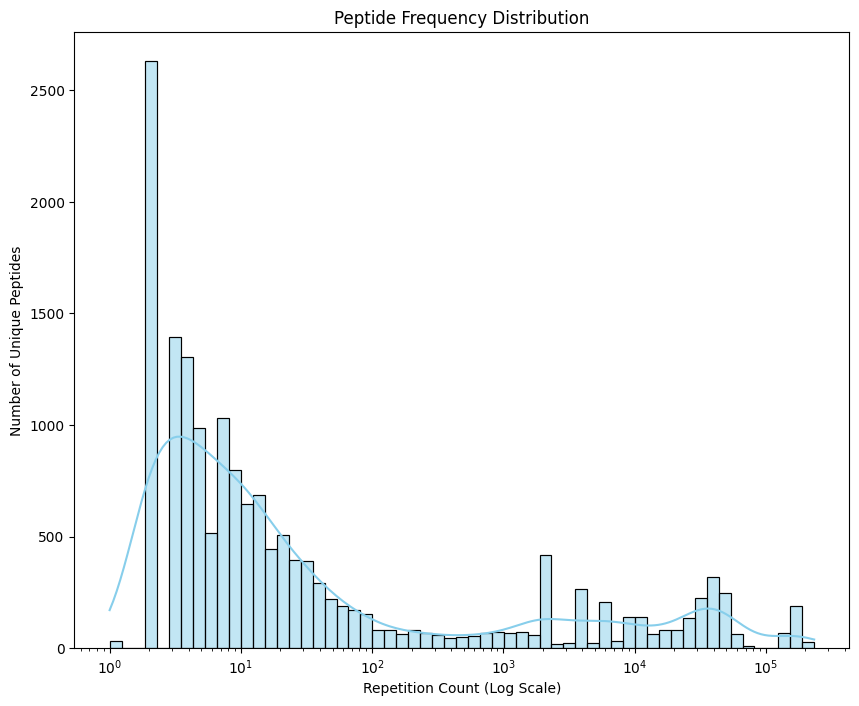

In [10]:
fig = plt.subplots(figsize=(10, 8))

sns.histplot(df_pept_freq["count"],log_scale = True,  kde=True, color='skyblue')

plt.title('Peptide Frequency Distribution')
plt.xlabel('Repetition Count (Log Scale)')
plt.ylabel('Number of Unique Peptides')

plt.show()


 This graph shows how many times each unique peptide is repeated on a logarithmic scale. A huge number of unique peptides (more than 2.500) clustered within the 10^0 and 10^1 range. This indicates that while the majority of peptides occur only a few times within the mapping file, a small fraction of highly frequent peptides dominate the dataset reaching more than 10^5 occurence.

#### Counts per Family (Bar Plot for Top Groups)

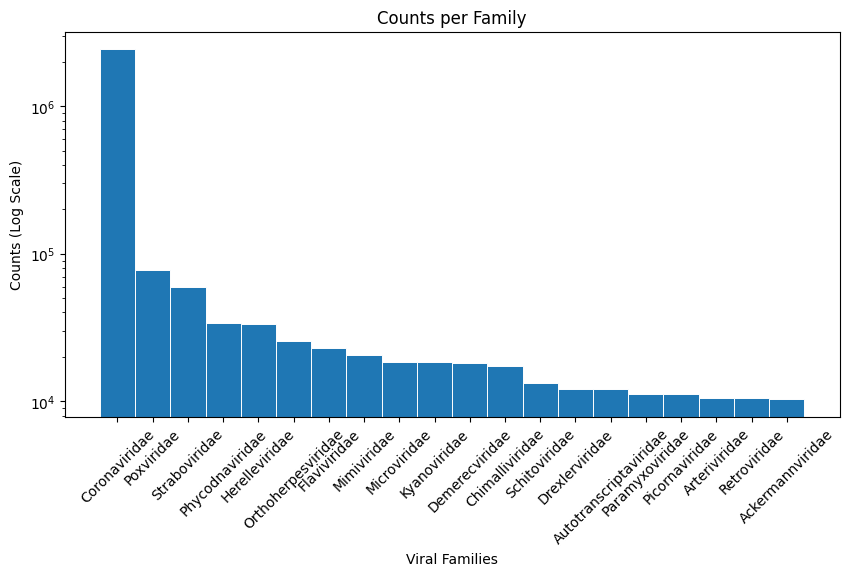

In [11]:
fig, ax= plt.subplots(figsize=(10, 5))

ax.bar(most_freq_family["family"], most_freq_family["counts"], width=1, edgecolor="white", linewidth=0.7)
ax.set_title("Counts per Family")
ax.set_xlabel("Viral Families")
ax.set_ylabel("Counts (Log Scale)")
plt.yscale("log")
plt.xticks(rotation=45)

plt.show()

 According to this graph, Coronaviridae is the most frequently observed viral family, followed by the Poxviridae. Apart from Coronaviridiae family, the families seen towards the end of the graph have similar frequencies with minor differences.

 The reason why the Coronaviridae family is more prevalent than other families may be due to acute global pandemics like, COVID-19. Millions of complete genomes were sequenced and uploaded to NCBI to track variants of the virus.

# Findings

- The primary dataset for the core analysis consisted of a mapped peptide file containing 97.744.896 rows and 4 columns. Metadata file contained 4.353.709 rows and 9 columns, providing the necessary taxonomic annotations for the mapped peptides.

- Mapped peptide file was structurally cleaned which did not contain any missing values and duplicated rows. On the other hand, the metadata contained completely missing values, both at the species level and in the family_x field. Furthermore, family-level descriptions were largely incomplete, reflecting inadequate metadata coverage for some peptides.

- The frequency of the most common peptides were generally close to each other, ranging from 230,000 to 190,000. This indicates that the mapped peptide chart is dominated by multiple peptides, rather than a single peptide or a few peptides. LLQNGMNGR is the most frequently occurring peptide.

- The prevalence of the most frequent 20 peptides was analyzed based on their side (human/virus) to evaluate potential molecular mimicry. The results revealed that nearly all of these top 20 peptides were predominantly of viral origin. Only the QNGMNGRTI peptide was seen 4 times in the mapped data for humans.

- Peptides exhibiting high human-viral overlap were not among the most frequently observed sequences. These motifs generally occurred with low frequency within the mapped data and are potentially molecular mimicry candidates.

- The most frequently occurring accessions of proteins were ranged between 170 and 150. Top 20 proteins showed a similar distribution within the mapped peptide data.

- Taxid 2697049 is the most prevalent identifier in the mapped peptide dataset, occurring 2,427,040 times. Its overwhelming dominance results in a highly non-homogeneous distribution across the mapped peptide dataset.

- Coronaviridae is the most frequent family, accounting for nearly all peptide mapping data, with 2.444.557 repeats. This shows that the overall mapped peptide data is heavily driven by a single viral family.

- According to the Peptide Frequency Distribuiton graph, while the majority of peptides occured only a few times within the mapping file, a small fraction of high-frequency peptides dominated the dataset.